In [2]:
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])
trainset = datasets.CIFAR10(
    root="/DATA/suraj/pr2/datasets",
    train=True,
    download=True,
    transform=train_transform
)

testset = datasets.CIFAR10(
    root="/DATA/suraj//pr2/datasets",
    train=False,
    download=True,
    transform=test_transform
)

print("CIFAR-10 downloaded successfully")


CIFAR-10 downloaded successfully


Using GPU: NVIDIA L4
Epoch [1/10] | Train Loss: 1.9367 | Val Loss: 1.6923
Epoch [2/10] | Train Loss: 1.6160 | Val Loss: 1.4721
Epoch [3/10] | Train Loss: 1.4656 | Val Loss: 1.3785
Epoch [4/10] | Train Loss: 1.3378 | Val Loss: 1.3187
Epoch [5/10] | Train Loss: 1.2560 | Val Loss: 1.2231
Epoch [6/10] | Train Loss: 1.1649 | Val Loss: 1.0822
Epoch [7/10] | Train Loss: 1.1010 | Val Loss: 1.1462
Epoch [8/10] | Train Loss: 1.0420 | Val Loss: 1.0885
Epoch [9/10] | Train Loss: 0.9862 | Val Loss: 0.9851
Epoch [10/10] | Train Loss: 0.9331 | Val Loss: 0.9439


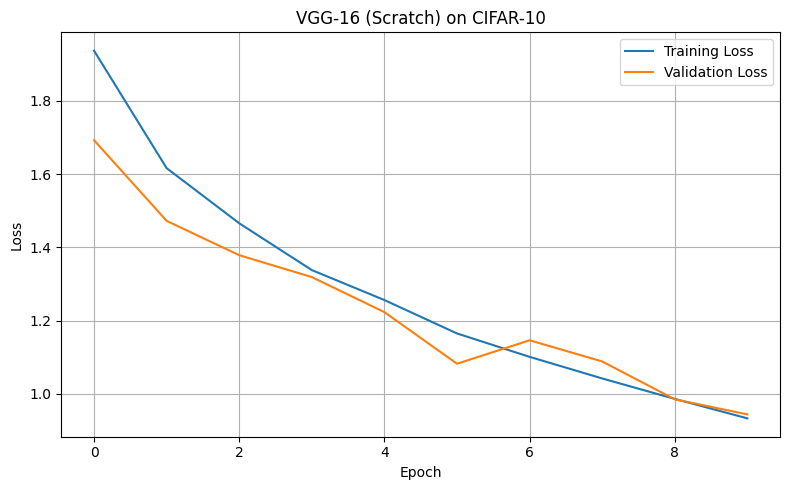

Model saved as aug_vgg16_cifar10_scratch.pth


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision import models
import matplotlib.pyplot as plt
import os

# ==================================================
# 1. DEVICE SETUP
# ==================================================
assert torch.cuda.is_available(), "CUDA not available"
device = torch.device("cuda:0")
torch.cuda.set_device(0)
torch.backends.cudnn.benchmark = True
print("Using GPU:", torch.cuda.get_device_name(0))

# ==================================================
# 2. HYPERPARAMETERS
# ==================================================
BATCH_SIZE = 256
EPOCHS = 10
LR = 1e-4
NUM_CLASSES = 10
NUM_WORKERS = min(8, os.cpu_count())
PIN_MEMORY = True

# ==================================================
# 3. DATA TRANSFORMS
# ==================================================
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

# ==================================================
# 4. DATASET (CIFAR-10)
# ==================================================
full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

# Train / Validation split
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size]
)

# ==================================================
# 5. DATALOADERS
# ==================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True
)

# ==================================================
# 6. MODEL: VGG-16 (SCRATCH, CIFAR-10 FIXED)
# ==================================================
model = models.vgg16(weights=None)

# CIFAR-10 friendly first conv
model.features[0] = nn.Conv2d(
    in_channels=3,
    out_channels=64,
    kernel_size=3,
    stride=1,
    padding=1
)

# CRITICAL FIX (prevents 25088 error)
model.avgpool = nn.AdaptiveAvgPool2d((1, 1))

model.classifier = nn.Sequential(
    nn.Linear(512, 512),
    nn.ReLU(True),
    nn.Dropout(0.5),
    nn.Linear(512, NUM_CLASSES)
)

model = model.to(device)

# ==================================================
# 7. LOSS & OPTIMIZER
# ==================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ==================================================
# 8. TRAINING + VALIDATION
# ==================================================
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # -------- TRAIN --------
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

# ==================================================
# 9. PLOT LOSSES
# ==================================================
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG-16 (Scratch) on CIFAR-10")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("vgg16_cifar10_loss.png")
plt.show()

# ==================================================
# 10. SAVE MODEL
# ==================================================
torch.save(model.state_dict(), "vgg16_cifar10_scratch.pth")
print("Model saved as aug_vgg16_cifar10_scratch.pth")


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 10

# Recreate exact same architecture
model = models.vgg16(weights=None)

model.features[0] = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
model.avgpool = nn.Identity()

model.classifier = nn.Sequential(
    nn.Linear(512, 512),
    nn.ReLU(True),
    nn.Dropout(0.5),
    nn.Linear(512, NUM_CLASSES)
)

# Load saved weights
model.load_state_dict(torch.load("aug_vgg16_cifar10_scratch.pth"))
model = model.to(device)

model.eval()

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [13]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

BATCH_SIZE = 256
NUM_WORKERS = min(8, os.cpu_count())

transform = transforms.Compose([
   transforms.ToTensor(),
    transforms.Resize((224, 224)),
])


test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

classes = test_dataset.classes
print("Test Loader Ready!")

Test Loader Ready!


In [ ]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Final Test Accuracy: {test_acc:.2f}%")

OutOfMemoryError: CUDA out of memory. Tried to allocate 3.06 GiB. GPU 0 has a total capacity of 22.03 GiB of which 591.06 MiB is free. Including non-PyTorch memory, this process has 21.44 GiB memory in use. Of the allocated memory 21.01 GiB is allocated by PyTorch, and 201.19 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

: 

In [5]:
import torch.nn.functional as F

model.eval()

failures = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        conf, preds = torch.max(probs, 1)

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                failures.append({
                    "image": images[i].cpu(),
                    "true": labels[i].item(),
                    "pred": preds[i].item(),
                    "confidence": conf[i].item()
                })

        if len(failures) >= 20:
            break

print(f"Collected {len(failures)} failure cases")

Collected 88 failure cases


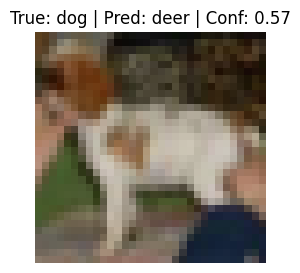

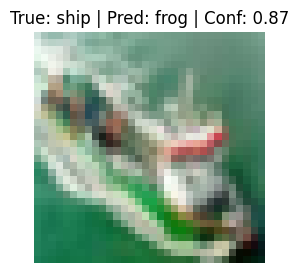

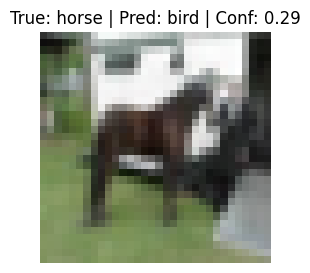

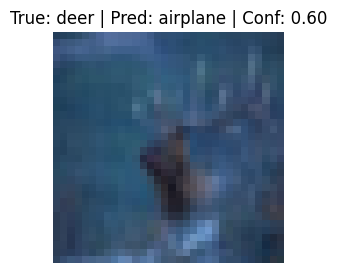

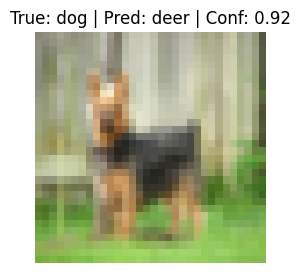

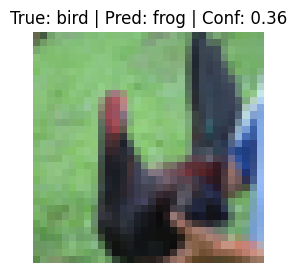

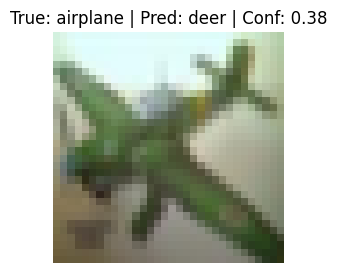

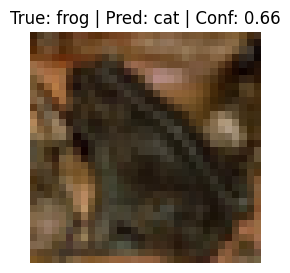

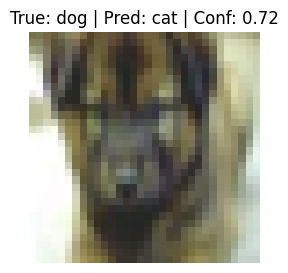

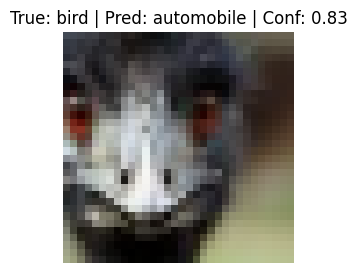

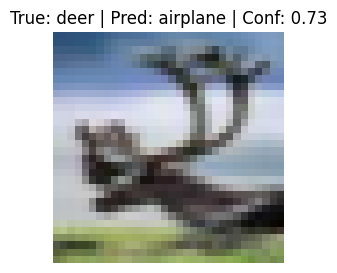

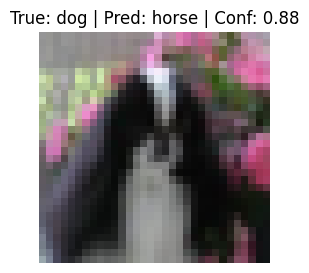

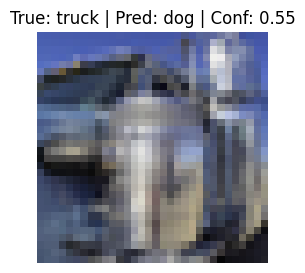

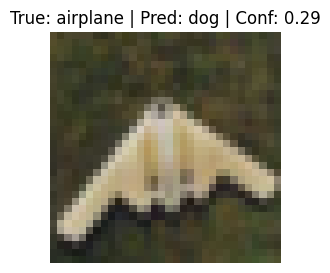

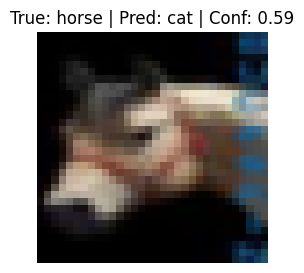

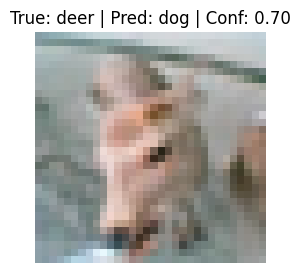

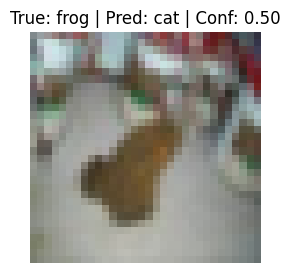

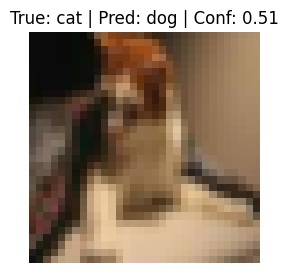

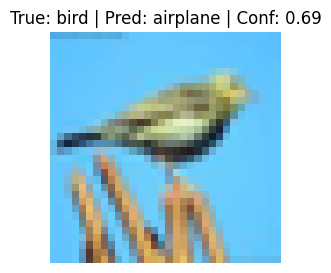

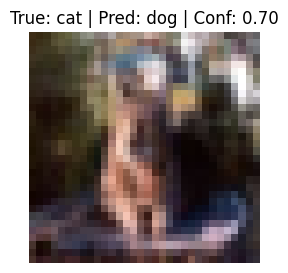

In [7]:
import matplotlib.pyplot as plt

for i, f in enumerate(failures[:20]):
    img = f["image"].permute(1,2,0)

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"True: {classes[f['true']]} | Pred: {classes[f['pred']]} | Conf: {f['confidence']:.2f}")
    plt.axis("off")
    plt.show()

In [ ]:
#!pip install grad-cam

In [ ]:
# ============================================================
# 1. Imports
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import numpy as np
import cv2
import os

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# ============================================================
# 2. Device
# ============================================================
assert torch.cuda.is_available(), "CUDA not available"
device = torch.device("cuda")
print("Using GPU:", torch.cuda.get_device_name(0))


#============================================================
#3. Dataset (CIFAR-10 → resized for VGG)
#============================================================
transform = train_transform.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
   
])

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)


# ============================================================
# 4. Model (VGG16)
# ============================================================
model = models.vgg16(weights=None)
model.classifier[6] = nn.Linear(4096, 10)
model.to(device)

# OPTIONAL: load trained weights
# model.load_state_dict(torch.load("vgg16_trained.pth"))

model.eval()

# ============================================================
# 5. Collect failure samples
# ============================================================
failures = []

with torch.no_grad():
    for img, label in test_loader:
        img = img.to(device)
        label = label.item()

        logits = model(img)
        pred = logits.argmax(dim=1).item()

        if pred != label:
            failures.append({
                "image": img[0].cpu(),   # normalized tensor
                "true": label,
                "pred": pred
            })

        if len(failures) >= 20:
            break

print(f"Collected {len(failures)} failure samples")


# ============================================================
# 6. Grad-CAM setup
# ============================================================
target_layers = [model.features[16]]   # conv3_3 → high resolution

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

os.makedirs("gradcam", exist_ok=True)

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])


# ============================================================
# 7. Grad-CAM visualization
# ============================================================
for i, case in enumerate(failures):

    # -------- Input --------
    input_tensor = case["image"].unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)

    true_label = case["true"]
    pred_label = case["pred"]

    targets = [ClassifierOutputTarget(pred_label)]

    # -------- Grad-CAM --------
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets,
        eigen_smooth=True
    )[0]

    # -------- Confidence --------
    with torch.no_grad():
        probs = torch.softmax(model(input_tensor), dim=1)
        conf = probs[0, pred_label].item()

    # -------- De-normalize image --------
    rgb_img = case["image"].permute(1, 2, 0).numpy()
    rgb_img = (rgb_img * IMAGENET_STD) + IMAGENET_MEAN
    rgb_img = np.clip(rgb_img, 0, 1)

    # -------- Overlay CAM --------
    cam_image = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    # -------- Convert to uint8 --------
    orig_uint8 = (rgb_img * 255).astype(np.uint8)
    cam_uint8  = cam_image.astype(np.uint8)

    # -------- Side-by-side --------
    combined = np.hstack([orig_uint8, cam_uint8])

    # 🔥 IMPORTANT FIX (OpenCV error)
    combined = np.ascontiguousarray(combined)

    # -------- Text --------
    text = f"T={true_label}  P={pred_label}  Conf={conf:.2f}"
    cv2.putText(
        combined,
        text,
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    # -------- Save --------
    filename = f"gradcam/failure_{i}.png"
    cv2.imwrite(filename, cv2.cvtColor(combined, cv2.COLOR_RGB2BGR))

    print(f"Saved {filename}")


Using GPU: NVIDIA L4
Collected 20 failure samples
Saved gradcam/failure_0.png
Saved gradcam/failure_1.png
Saved gradcam/failure_2.png
Saved gradcam/failure_3.png
Saved gradcam/failure_4.png
Saved gradcam/failure_5.png
Saved gradcam/failure_6.png
Saved gradcam/failure_7.png
Saved gradcam/failure_8.png
Saved gradcam/failure_9.png
Saved gradcam/failure_10.png
Saved gradcam/failure_11.png
Saved gradcam/failure_12.png
Saved gradcam/failure_13.png
Saved gradcam/failure_14.png
Saved gradcam/failure_15.png
Saved gradcam/failure_16.png
Saved gradcam/failure_17.png
Saved gradcam/failure_18.png
Saved gradcam/failure_19.png
